In [1]:
import transformers
import torchaudio
import torchcodec
import os
from pathlib import Path
import pickle
import random
import sys
import numpy as np
import torch

In [2]:
audio_dir = '/kaggle/input/datasets/growingsun/cadence-chunks/preprocessed_dir/'

In [3]:
pkl_file = '/kaggle/input/datasets/growingsun/kmeans-stage1/kmeans_stage1_n100.pkl'

with open(pkl_file, 'rb') as file:
    kmeans_stage1 = pickle.load(file)

In [4]:
kmeans_stage1

MiniBatchKMeans(batch_size=10000, n_clusters=100, n_init=10, random_state=42)

<h3>Custom Dataset</h3>

In [5]:
import torch
from torch.utils.data import Dataset, DataLoader
import torchaudio.transforms as T
from torchcodec.decoders import AudioDecoder

<p>we have used the mfcc (1001,39) of each song to cluster labels using kmeans </p>
<p>that label is predicted to use as label for hubert training</p>

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [7]:
def precompute_labels(audio_dir, kmeans, output_dir):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents = True, exist_ok = True)

    #mfcc_transfrom function
    mfcc_transform = T.MFCC(
        sample_rate = 16000, #16kHz,
            n_mfcc = 39,
            melkwargs = {"n_fft": 400, "hop_length": 160, "n_mels": 80})

    #get all the file paths in the audio_dir
    files = []
    for genre_dir in Path(audio_dir).iterdir():
        if genre_dir.is_dir():
            files.extend(list(genre_dir.glob('*')))

    #predict label for each of the audio chunks
    for f in tqdm(files):
        label_path = output_dir / (f.stem + ".npy") 
        if label_path.exists():
            continue #skip if already computed
    
        decoder = AudioDecoder(str(f), sample_rate = 16000)
        audio = decoder.get_all_samples()
        waveform = audio.data
    
        mfcc = mfcc_transform(waveform).squeeze(0).T.numpy()
        labels = kmeans.predict(mfcc)
        
        #save it in the working directory
        np.save(str(label_path), labels)
        # print(f'saved in {label_path}')
    # don't forget to download it

    print("....Computed labels pre-training ....")

In [8]:
from tqdm.notebook import tqdm
# labels_output_dir = '/kaggle/working/labels/'
# precompute_labels(audio_dir = audio_dir, kmeans = kmeans_stage1, output_dir = labels_output_dir)

In [9]:
# import shutil

# shutil.make_archive(
#     "/kaggle/working/labels",
#     "zip",
#     "/kaggle/working/labels"
# )

In [10]:
class FolkAudioDataset(Dataset):
    def __init__(self, audio_dir, label_dir, feature_extractor, kmeans, max_length = 160000):
        self.files = []

        for genre_dir in Path(audio_dir).iterdir():
            if genre_dir.is_dir():
                self.files.extend(list((genre_dir).glob('*')))
        random.shuffle(self.files)

        self.feature_extractor = feature_extractor #wave2vec2 + needs to be stdudied properly
        self.kmeans = kmeans
        self.max_length = max_length

        self.mfcc = T.MFCC(
            sample_rate = 16000, #16kHz,
            n_mfcc = 39,
            melkwargs = {"n_fft": 400, "hop_length": 160, "n_mels": 80}
        )

        print(f"Dataset size : {len(self.files)}")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        #retrieve the file with the idx
        file = self.files[idx]

        #decoder the audio and get waveform
        decoder = AudioDecoder(str(file), sample_rate = 16000)
        audio = decoder.get_all_samples()
        waveform = audio.data.mean(dim = 0) #if audio is stereo, converts it to mono
        
        # retrieve the label from the label_dir
        label_path = Path(f'{label_dir}/{Path(file).stem}.npy')
        labels = torch.tensor(np.load(label_path), dtype= torch.long)
        
        inputs = self.feature_extractor(
            waveform.numpy(),
            sampling_rate = 16000,
            max_length = self.max_length,
            padding = "max_length",  #all the audioinputs are of same size through padding
            return_tensors = "pt",
            truncation = True
        )

        return inputs.input_values.squeeze(0), labels
        
        

In [11]:
from transformers import HubertModel, Wav2Vec2FeatureExtractor

In [12]:
# sample = '/kaggle/input/datasets/growingsun/cadence-chunks/preprocessed_dir/tamang_selo/Aama_Yangri_-_Phurpa_Syangpa_New_Nepali_Tamang_Selo_Himali_Selo_Song_2017_chunk000.wav'

# label_dir = '/kaggle/input/datasets/growingsun/precomputed-labels-zip'
# label_path = f'{label_dir}/{Path(sample).stem}.npy'


# label = np.load(label_path)
# label.shape

In [13]:
label_dir = '/kaggle/input/datasets/growingsun/precomputed-labels-zip/'
feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained("facebook/hubert-base-ls960")
dataset = FolkAudioDataset(audio_dir, label_dir, feature_extractor, kmeans = kmeans_stage1)

preprocessor_config.json:   0%|          | 0.00/213 [00:00<?, ?B/s]

Dataset size : 11450


In [14]:
def collate_fn(batch):
    input_values, labels = zip(*batch) #unpacks each input to inputs and each label to labels
    #each input is already of size 160000
    #convert to (B, 160000)

    input_values = torch.stack(input_values, dim=0)

    #label are not of same size
    #make all label equal to max length of label in the batch

    max_len = max([l.shape[0] for l in labels])
    padded_labels = torch.full(
        (len(labels), max_len),
        fill_value = -100,
        dtype = torch.long
    )

    #fill the real value
    for i, label in enumerate(labels):
        padded_labels[i, :label.shape[0]] = label

    # print(input_values.shape, padded_labels.shape)
    return input_values, padded_labels

In [15]:
dataloader = DataLoader(dataset, batch_size = 8, shuffle= True, collate_fn = collate_fn, num_workers = 4) 

In [16]:
from transformers import HubertModel, HubertConfig
import torch
import torch.nn as nn

<ul>
    <li>Hubert Base ls-960</li>
    <li>Hubert Architecture</li>
    
</ul>

<h3>Hubert Architecture</h3>

<ul>
    <li> 7 layer CNN feature extractor to convect raw audio to usable continuous features</li>
</ul>

<ul>
    <li> Grouped conv divides the output 768 neurons into 16 groups. Each group has 48 neurons.</li>
    <li> For each timestep t, 48 output neurons are connected to 48 input neurons only. Not the neurons of the other group</li>
    <li> 48 output neurons of group 1 are not connected all the 768 input channels of timestep t</li>
</ul>

<p> __RuntimeError__ : stack expects each tensor to be equal size, but got [1001] at entry 0 and [706] at entry 6 </p>

<p>The above error is because collate_fn hasn't been used to pad the tensor</p>
<p>Use custom collate_fn function</p>

In [17]:
def setup_model(unfreeze_top_n = 6):
    model = HubertModel.from_pretrained("facebook/hubert-base-ls960")
    #first freeze all the layers
    for param in model.parameters():
        param.requires_grad = False
    
    total_layers = len(model.encoder.layers)
    # print(total_layers)
    
    unfreeze_top_n = 6
    for i in range(total_layers - unfreeze_top_n, total_layers):
        for param in model.encoder.layers[i].parameters():
            param.requires_grad = True
    
    #unfreezing the layer norm because the original alpha and beta value, obtained through english sound dataset cannot normalize the nepali songs dataset
    for param in model.encoder.layer_norm.parameters():
        param.requires_grad = True
    
    trainable = sum(p.numel()for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p  in model.parameters())
    print(f"Trainable: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")
    return model

In [18]:
def create_mask(B, T, device,  mask_length = 10, mask_prob = 0.065):
    """
    B: num_batches = 8
    T: num_timesteps  = 499
    D:  num_dimension of each timestep = 768
    """
    
    mask = torch.zeros(B, T, dtype = torch.bool, device = device)
    num_spans = max(1, int(T * mask_prob)) # 32 positions to be masked

    for b in range(0,B):
    #random mask
        starts = torch.randint(low =0, high = T - mask_length, size=(num_spans,), dtype=torch.int32)   
        for start in starts:
            mask[b, start: start+mask_length] = True
            #mask consecutive span of frames
    
    return mask
    

In [19]:
from tqdm.notebook import tqdm
output_dir = '/kaggle/working/'
epochs = 20

In [20]:
# for input_values, labels in dataloader:
#     print(f"input_values shape : {input_values.shape}")   # (8, 160000)
#     print(f"labels shape       : {labels.shape}")          # (8, T_mfcc)
#     print(f"label min          : {labels.min().item()}")   # >= -100
#     print(f"label max          : {labels.max().item()}")   # <= 99
#     break

# model = setup_model()
# print(f"Model type: {type(model)}")   # HubertModel, not random init

# device = torch.device("cuda")
# model      = setup_model().to(device)
# classifier = nn.Linear(768, 100).to(device)
# loss_fn    = nn.CrossEntropyLoss(ignore_index=-100)

# input_values, labels = next(iter(dataloader))
# input_values = input_values.to(device)
# labels       = labels.to(device)

# hidden = model(input_values).last_hidden_state
# B, T_hubert, D = hidden.shape
# print(f"Hidden shape : {hidden.shape}")   # (8, 499, 768)

# mask = create_mask(B, T_hubert, device)
# print(f"Mask shape   : {mask.shape}")     # (8, 499)
# print(f"Masked frames: {mask.sum()}")     # ~250

# T_mfcc = labels.shape[1]
# labels = torch.nn.functional.interpolate(
#     labels.float().unsqueeze(1),
#     size=T_hubert, mode="nearest"
# ).squeeze(1).long()
# print(f"Aligned labels shape: {labels.shape}")  # (8, 499)

# masked_hidden = hidden[mask]
# masked_labels = labels[mask]

# valid         = (masked_labels >= 0) & (masked_labels < 100)
# masked_hidden = masked_hidden[valid]
# masked_labels = masked_labels[valid]
# print(f"Valid masked frames: {valid.sum()}")   # should be close to mask.sum()

# logits = classifier(masked_hidden)
# loss   = loss_fn(logits, masked_labels)
# print(f"Loss: {loss.item()}")   # should be close to log(100) = 4.60

In [21]:
def train(dataloader, epochs = 20, batch_size =8, lr = 5e-5, output_dir = output_dir):
    
    print(f'device = ',device)

    #------------------------------------------------------------#
    model = setup_model().to(device)
    classifier = nn.Linear(768,100).to(device)

    #-----------------------------------------------------------#
    optimizer = torch.optim.AdamW(
    list(filter(lambda p: p.requires_grad, model.parameters()))+
    list(classifier.parameters()),
    lr = 5e-5 ,#0.00005,
    weight_decay = 0.01)
    
    #cosine annealing is used for learning rate scheduling 
    #smooth lr decay
    
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max = epochs * len(dataloader)
    )
    
    loss_fn = nn.CrossEntropyLoss(ignore_index = -100)

    #-----------------------------------------------------------#

    if not dataloader or not optimizer or not scheduler or not model:
        print(f'All the required parameters are not passed to the train function')
        sys.exit()

    print(f'Dataloader loaded')
    print(f'Oprtimizer loaded')
    print(f'Scheduler loaded')
    print(f'Model loaded')

    epoch_bar = tqdm(range(epochs), desc = "Epochs", position = 0)
    history = {
        'train_loss' : [],
        'epoch_loss' : [],
    }
    
    for epoch in epoch_bar:
        model.train()
        classifier.train()
        total_loss = 0.0
        total_masked = 0
    
        step_bar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}", position=1, leave=False )
    
        for step, (input_values, labels) in enumerate(step_bar):
            input_values = input_values.to(device) #(8, 160000)
            labels = labels.to(device) #(8, 1001)
            
            optimizer.zero_grad()
        
            #hubert forward pass
            hidden_state = model(input_values).last_hidden_state
    
            B, T_hubert, D = hidden_state.shape
            #create masks 
            mask = create_mask(B, T_hubert, D)
        
            #make inputs' timesteps (499) and labels' timesteps (1001) equal 
            T_mfcc  = labels.shape[1]
            
            #interpolate
            if T_mfcc != T_hubert:
                labels = torch.nn.functional.interpolate(
                    labels.float().unsqueeze(1),
                    size = T_hubert,
                    mode = "nearest"
                ).squeeze(1).long()
        
            #new labels shape = (8,499)
            masked_hidden = hidden_state[mask]
            masked_labels = labels[mask]
    
            #predict cluster IDs and compute loss 
            valid         = (masked_labels >= 0) & (masked_labels < 100)
            masked_hidden = masked_hidden[valid]
            masked_labels = masked_labels[valid]
            
            if masked_labels.numel() > 0:
                logits = classifier(masked_hidden)   # (N, 100)
                loss   = loss_fn(logits, masked_labels)
            else:
                continue
        
            #backprop
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            total_loss += loss.item()

            # Check this in your training loop
            # print(f"Masked frames  : {mask.sum().item()}")
            # print(f"Valid frames   : {valid.sum().item()}")
            # print(f"Loss           : {loss.item():.6f}")
            
            history['train_loss'].append(loss.item())
            total_masked += mask.sum().item()
    
            step_bar.set_postfix({
                "loss" : f"{loss.item():.4f}",
                "masked" : mask.sum().item(),
                "lr" : f"{scheduler.get_last_lr()[0]:.2e}"
            })
            # break
            
        avg_loss = total_loss / len(dataloader)

        print(f'average_loss = {avg_loss},{type(avg_loss)}')

        history['epoch_loss'].append(avg_loss)
        epoch_bar.set_postfix({
            "avg_loss"     : f"{avg_loss:.4f}",
            "total_masked" : f"{total_masked:,}"
            })
    
         # Save checkpoint every 5 epochs
        if (epoch + 1) % 5 == 0:
            ckpt = f"{output_dir}/checkpoint-epoch{epoch+1}"
            model.save_pretrained(ckpt)
            feature_extractor.save_pretrained(ckpt)
            torch.save(classifier.state_dict(), f"{ckpt}/classifier.pt")
            tqdm.write(f"Checkpoint saved → {ckpt}")
            
    return history
    


In [22]:
history = train(dataloader = dataloader , epochs = 20, batch_size =8, lr = 5e-5)

device =  cuda


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/378M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

...

average_loss = 1.7352638903110387,<class 'float'>


Epoch 20/20:   0%|          | 0/1432 [00:00<?, ?it/s]

average_loss = 1.7510602611569719,<class 'float'>


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Checkpoint saved → /kaggle/working//checkpoint-epoch20


In [23]:
import matplotlib.pyplot as plt

In [24]:
import pickle

with open('/kaggle/working/history.pkl','wb') as file:
    pickle.dump(history, file)

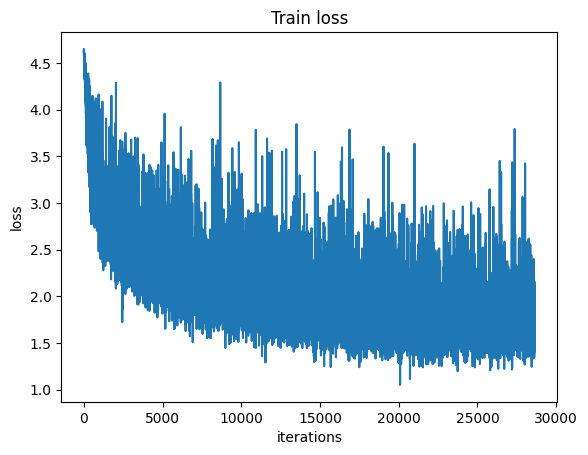

In [25]:
plt.title('Train loss')
plt.xlabel('iterations')
plt.ylabel('loss')
plt.plot(history['train_loss'])
plt.savefig('/kaggle/working/loss.png')

<ul>
    <li>DataLoader alone: 0.067s per batch</li>
    <li> Training step alone: 0.969s per batch</li>
</ul>

<ul>
    <li> Predicting the label of the frame of a timestep given the surrounding frames /// context</li>
</ul>

In [26]:
# B, T_hubert, D = hidden_state.shape

# T_mfcc = labels.shape[1]
# #mfcc has 1001 timesteps, whereas the CNN encoder of Hubert has made 499 timesteps for each audio

In [27]:
# #the timestep of input_values is 499 whereas the labels for each input_value has 1001 timesteps
# # this is because input_values is obtained through CNN feature extractor Wave2Vec2 but labels is through MFCC
# # The size of the label should also be made 499

# if T_mfcc !=  T_hubert:
#     #make them the same
#     labels = torch.nn.functional.interpolate(
#         labels.float().unsqueeze(1), 
#         size = T_hubert,
#         mode = "nearest"
#     ). squeeze(1).long()

In [28]:
# print(hidden_state.shape, mask.shape, labels.shape)
# #mask contains info about which positions in the hidden_state are masked
# masked_hidden = hidden_state[mask]
# masked_labels =labels[mask]

In [29]:
# masked_hidden.shape, masked_labels.shape

In [30]:
# logits = classifier(masked_hidden)
# logits.shape

In [31]:
# loss = loss_fn(logits, masked_labels)
# loss